# Анализ временного ряда усреднения банковских резервов

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_excel('../../data/raw/m1_required_reserves/required_reserves_table.xlsx')

In [32]:
df.head()

,Обязательные резервы кредитных организаций,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Обязательные резервы1;2;3;4;5 и средства на ко...,NaN,NaN,Количество кредитных организаций:,NaN,Справочно:,NaN,NaN,NaN
1,Период усреднения\nобязательных резервов\n(ука...,Фактические среднедневные остатки средств на к...,"Обязательные резервы, подлежащие усреднению на...",Обязательные резервы на счетах для их учета4,пользующихся правом усреднения обязательных ре...,действующих1,период усреднения обязательных резервов,число календарных дней в периоде усреднения об...,отчетный период6,период регулирования обязательных резервов7
2,2004-09-01 00:00:00,195.456667,8.7,116,492,1316,2004-09-01 00:00:00,30,01.08.2004 — 01.09.2004,03.09.2004 — 08.09.2004
3,2004-10-01 00:00:00,231.540323,9.1,117.3,503,1315,2004-10-01 00:00:00,31,01.09.2004 — 01.10.2004,05.10.2004 — 08.10.2004
4,2004-11-01 00:00:00,282.488333,11.5,118.9,521,1311,2004-11-01 00:00:00,30,01.10.2004 — 01.11.2004,03.11.2004 — 09.11.2004


In [33]:
df.describe()

,Обязательные резервы кредитных организаций,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
count,269,261.0,261.0,261.0,262,261,262,261,261,261
unique,269,260.0,260.0,223.0,175,205,262,7,261,261
top,Период усреднения\nобязательных резервов\n(ука...,1464.9,19.2,145.9,360,360,Справочно:,28,отчетный период6,период регулирования обязательных резервов7
freq,1,2.0,2.0,7.0,10,9,1,89,1,1


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Обязательные резервы кредитных организаций  269 non-null    object
 1   Unnamed: 1                                  261 non-null    object
 2   Unnamed: 2                                  261 non-null    object
 3   Unnamed: 3                                  261 non-null    object
 4   Unnamed: 4                                  262 non-null    object
 5   Unnamed: 5                                  261 non-null    object
 6   Unnamed: 6                                  262 non-null    object
 7   Unnamed: 7                                  261 non-null    object
 8   Unnamed: 8                                  261 non-null    object
 9   Unnamed: 9                                  261 non-null    str   
dtypes: object(9), str(1)
memory usage: 21

In [37]:
df.columns = df.iloc[0]
df=df[1:]
df.reset_index(drop=True, inplace=True)
df.head()

,Период усреднения\nобязательных резервов\n(указан первый день),Фактические среднедневные остатки средств на корсчетах3,"Обязательные резервы, подлежащие усреднению на корсчетах4",Обязательные резервы на счетах для их учета4,пользующихся правом усреднения обязательных резервов1,действующих1,период усреднения обязательных резервов,число календарных дней в периоде усреднения обязательных резервов,отчетный период6,период регулирования обязательных резервов7
0,2004-09-01 00:00:00,195.456667,8.7,116,492,1316,2004-09-01 00:00:00,30,01.08.2004 — 01.09.2004,03.09.2004 — 08.09.2004
1,2004-10-01 00:00:00,231.540323,9.1,117.3,503,1315,2004-10-01 00:00:00,31,01.09.2004 — 01.10.2004,05.10.2004 — 08.10.2004
2,2004-11-01 00:00:00,282.488333,11.5,118.9,521,1311,2004-11-01 00:00:00,30,01.10.2004 — 01.11.2004,03.11.2004 — 09.11.2004
3,2004-12-01 00:00:00,368.259677,12,121.7,523,1304,2004-12-01 00:00:00,31,01.11.2004 — 01.12.2004,03.12.2004 — 08.12.2004
4,2005-01-01 00:00:00,356.675806,12.7,171.6,650,1300,2005-01-01 00:00:00,31,01.12.2004 — 01.01.2005,13.01.2005 — 18.01.2005


In [38]:
df.drop(columns=['пользующихся правом усреднения обязательных резервов1','действующих1','отчетный период6','период регулирования обязательных резервов7'],inplace=True)

In [39]:
df.rename(columns={'Период усреднения\nобязательных резервов\n(указан первый день)':'Дата','Фактические среднедневные остатки средств на корсчетах3': "фактические остатки","Обязательные резервы, подлежащие усреднению на корсчетах4":"обязательные резервы"},inplace=True)
df.head()

,Дата,фактические остатки,обязательные резервы,Обязательные резервы на счетах для их учета4,период усреднения обязательных резервов,число календарных дней в периоде усреднения обязательных резервов
0,2004-09-01 00:00:00,195.456667,8.7,116,2004-09-01 00:00:00,30
1,2004-10-01 00:00:00,231.540323,9.1,117.3,2004-10-01 00:00:00,31
2,2004-11-01 00:00:00,282.488333,11.5,118.9,2004-11-01 00:00:00,30
3,2004-12-01 00:00:00,368.259677,12,121.7,2004-12-01 00:00:00,31
4,2005-01-01 00:00:00,356.675806,12.7,171.6,2005-01-01 00:00:00,31


In [40]:
df.tail()

,Дата,фактические остатки,обязательные резервы,Обязательные резервы на счетах для их учета4,период усреднения обязательных резервов,число календарных дней в периоде усреднения обязательных резервов
264,4 Данные публикуются на 16-ый рабочий день мес...,NaN,NaN,NaN,NaN,NaN
265,5 С учетом результатов внеочередного регулиров...,NaN,NaN,NaN,NaN,NaN
266,6 Расчет размера резервируемых обязательств из...,NaN,NaN,NaN,NaN,NaN
267,7 Для отчетных периодов с августа 2004 г. по д...,NaN,NaN,NaN,NaN,NaN
268,"8 В скобках: количество кредитных организаций,...",NaN,NaN,NaN,NaN,NaN


In [41]:
df.dropna(how='any',inplace=True)

In [42]:
df['Дата'] = pd.to_datetime(df['Дата'])
for col in df.columns.drop('Дата'):
    if col != 'период усреднения обязательных резервов':
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

df.sort_values('Дата', inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()

,Дата,фактические остатки,обязательные резервы,Обязательные резервы на счетах для их учета4,период усреднения обязательных резервов,число календарных дней в периоде усреднения обязательных резервов
0,2004-09-01,195.456667,8.7,116.0,2004-09-01 00:00:00,30.0
1,2004-10-01,231.540323,9.1,117.3,2004-10-01 00:00:00,31.0
2,2004-11-01,282.488333,11.5,118.9,2004-11-01 00:00:00,30.0
3,2004-12-01,368.259677,12.0,121.7,2004-12-01 00:00:00,31.0
4,2005-01-01,356.675806,12.7,171.6,2005-01-01 00:00:00,31.0


In [43]:
df['спред'] = df['фактические остатки'] - df['обязательные резервы']
df.head()

,Дата,фактические остатки,обязательные резервы,Обязательные резервы на счетах для их учета4,период усреднения обязательных резервов,число календарных дней в периоде усреднения обязательных резервов,спред
0,2004-09-01,195.456667,8.7,116.0,2004-09-01 00:00:00,30.0,186.756667
1,2004-10-01,231.540323,9.1,117.3,2004-10-01 00:00:00,31.0,222.440323
2,2004-11-01,282.488333,11.5,118.9,2004-11-01 00:00:00,30.0,270.988333
3,2004-12-01,368.259677,12.0,121.7,2004-12-01 00:00:00,31.0,356.259677
4,2005-01-01,356.675806,12.7,171.6,2005-01-01 00:00:00,31.0,343.975806


In [44]:
df['Дата'] = pd.to_datetime(df['Дата'])
for col in df.columns.drop('Дата'):
    if col!='период усреднения обязательных резервов':
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

df.sort_values('Дата', inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Дата,фактические остатки,обязательные резервы,Обязательные резервы на счетах для их учета4,период усреднения обязательных резервов,число календарных дней в периоде усреднения обязательных резервов,спред
0,2004-09-01,195.456667,8.7,116.0,2004-09-01 00:00:00,30.0,186.756667
1,2004-10-01,231.540323,9.1,117.3,2004-10-01 00:00:00,31.0,222.440323
2,2004-11-01,282.488333,11.5,118.9,2004-11-01 00:00:00,30.0,270.988333
3,2004-12-01,368.259677,12.0,121.7,2004-12-01 00:00:00,31.0,356.259677
4,2005-01-01,356.675806,12.7,171.6,2005-01-01 00:00:00,31.0,343.975806


In [45]:
# Загружаем дневные данные по RUONIA и готовим их для месячного анализа
ruonia = pd.read_excel('../../data/raw/m1_required_reserves/RC_F01_04_2010_T07_05_2026.xlsx')
ruonia.rename(columns={'DT': 'Дата', 'ruo': 'RUONIA'}, inplace=True)
ruonia['Дата'] = pd.to_datetime(ruonia['Дата'])
ruonia = ruonia.sort_values('Дата').reset_index(drop=True)

# Усредненная ставка RUONIA за календарный месяц и изменение в последние 5 дней месяца
ruonia['period_month'] = ruonia['Дата'].dt.to_period('M')
ruonia_month = (
    ruonia.groupby('period_month')
    .agg(
        RUONIA_avg=('RUONIA', 'mean'),
        RUONIA_delta_last5=('RUONIA', lambda x: x.tail(5).iloc[-1] - x.tail(5).iloc[0] if len(x.tail(5)) >= 2 else np.nan),
    )
    .reset_index()
)
ruonia_month['period_month'] = ruonia_month['period_month'].dt.to_timestamp('M')

# Сопоставляем месячные периоды RUONIA с данными по резервам
df['year_month'] = df['Дата'].dt.to_period('M')
ruonia_month['year_month'] = ruonia_month['period_month'].dt.to_period('M')

df = df.merge(ruonia_month[['year_month', 'RUONIA_avg', 'RUONIA_delta_last5']], how='left', on='year_month')
df.drop(columns=['year_month'], inplace=True)

# Функция MAD и стандартный scoring

def mad(values):
    values = np.asarray(values, dtype=float)
    median = np.nanmedian(values)
    return np.nanmedian(np.abs(values - median))

spred_median = df['спред'].rolling(window=36, min_periods=1).median()
spred_mad = df['спред'].rolling(window=36, min_periods=1).apply(mad, raw=True)
df['MAD_score_спред'] = ((df['спред'] - spred_median) / spred_mad.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

ruonia_median = df['RUONIA_avg'].rolling(window=36, min_periods=1).median()
ruonia_mad = df['RUONIA_avg'].rolling(window=36, min_periods=1).apply(mad, raw=True)
df['MAD_score_RUONIA'] = ((df['RUONIA_avg'] - ruonia_median) / ruonia_mad.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

# Флаг конца периода: сильный положительный спред и рост RUONIA в последние дни периода

df['Flag_EndOfPeriod'] = (
    (df['MAD_score_спред'] > 1) &
    (df['RUONIA_delta_last5'] > 0)
).astype(int)

# Дополнительно можно посмотреть результат
print(df[['Дата', 'спред', 'RUONIA_avg', 'RUONIA_delta_last5', 'MAD_score_спред', 'MAD_score_RUONIA', 'Flag_EndOfPeriod']].tail(10))

c:\Users\Huawei\python_programming\psb_case\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


          Дата   спред  RUONIA_avg  RUONIA_delta_last5  MAD_score_спред  \
249 2025-06-04   66.92   20.082105                0.50        -1.185246   
250 2025-07-09   45.20   19.283913               -0.89        -2.490909   
251 2025-08-13   55.00   17.733333                0.01        -1.787879   
252 2025-09-10   66.80   17.198636                0.08        -1.061947   
253 2025-10-08   65.10   16.494783                0.04        -1.184583   
254 2025-11-12   62.20   16.323684                0.01        -1.398121   
255 2025-12-10  120.90   16.040000               -0.22         2.843208   
256 2026-01-14   99.90   15.692667                0.19         1.211513   
257 2026-02-11  109.00   15.325263                0.00         1.716088   
258 2026-03-11  105.80   14.974762               -0.03         1.379310   

     MAD_score_RUONIA  Flag_EndOfPeriod  
249          0.866910                 0  
250          0.706282                 0  
251          0.408935                 0  
252   

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 12 columns):
 #   Column                                                             Non-Null Count  Dtype         
---  ------                                                             --------------  -----         
 0   Дата                                                               259 non-null    datetime64[us]
 1   фактические остатки                                                259 non-null    float64       
 2   обязательные резервы                                               259 non-null    float64       
 3   Обязательные резервы на счетах для их учета4                       259 non-null    float64       
 4   период усреднения обязательных резервов                            259 non-null    object        
 5   число календарных дней в периоде усреднения обязательных резервов  259 non-null    float64       
 6   спред                                                              259 non-nu

In [47]:
df_check = df[df['Flag_EndOfPeriod'] == 1]
print(df_check)

          Дата  фактические остатки  обязательные резервы  \
147 2016-12-08               1978.8                1765.6   
183 2019-12-11               2526.4                2427.8   
186 2020-03-11               2536.4                2430.8   
195 2020-12-09               2902.0                2790.7   
199 2021-04-07               3010.7                2934.1   
201 2021-06-09               3134.3                3032.0   
202 2021-07-07               3169.3                3038.5   
204 2021-09-08               3242.9                3104.1   
207 2021-12-08               3352.8                3207.4   
211 2022-04-13               1541.8                1420.9   
213 2022-06-15               1774.4                1631.2   
214 2022-07-13               1719.6                1568.7   
215 2022-08-10               1694.4                1562.1   
216 2022-09-14               2451.6                2320.5   
219 2022-12-14               2460.6                2322.1   
237 2024-06-05          

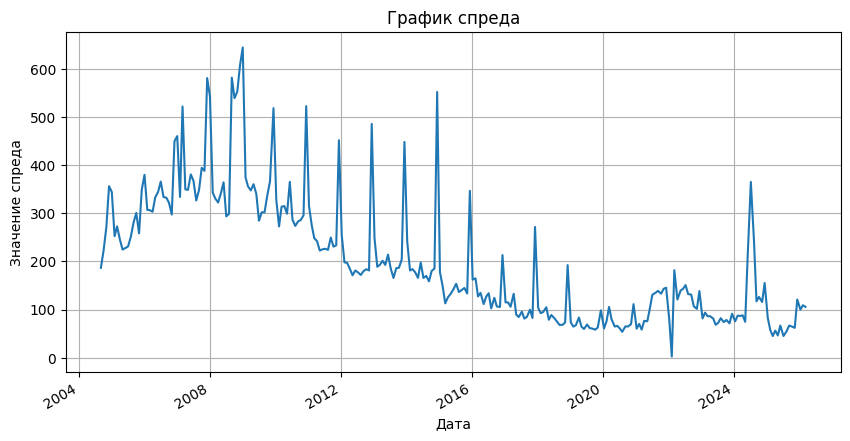

In [48]:
df.set_index('Дата', inplace=True)
df['спред'].plot(kind='line', title='График спреда', figsize=(10, 5))
plt.xlabel('Дата')
plt.ylabel('Значение спреда')
plt.grid(True)
plt.show()

Этот график — отличный результат для первого шага! Вы визуализировали "пульс" банковской системы России за 20 лет. 

Напомним экономический смысл: **Спред = Фактические деньги на корсчетах − Обязательные резервы**.
Если спред большой и положительный — банки держат в ЦБ денег **сильно больше**, чем от них требуют правила. 

Вот что детально говорит вам этот график, и как это применить к вашему Техническому заданию (ТЗ).

---

### 1. Ярко выраженная сезонность (Пики-«Иголки»)
Самое заметное на графике после 2012 года — это резкие, почти ритмичные выстрелы вверх, похожие на кардиограмму. 
*   **Что это экономически:** С вероятностью 99% эти пики приходятся на **декабрь/январь** каждого года. В России в конце года происходит традиционный "бюджетный навес" — Минфин экстренно тратит остатки годового бюджета. Огромные суммы денег попадают из бюджета на счета компаний в коммерческих банках, и эти деньги оседают на корсчетах банков в ЦБ. 
*   **Вывод для вас:** Спред регулярно взлетает не только из-за кризисов, но и из-за Нового года. Это норма.

### 2. Смена режимов ликвидности (Тренд)
График четко делится на две исторические эпохи:
*   **2004 — 2011 годы (Высокий базовый уровень):** Линия спреда болтается высоко (300–500). В те годы в России был структурный профицит ликвидности из-за высоких цен на нефть. ЦБ скупал валюту, вливая рубли в банки. Денег было так много, что банки постоянно держали огромные излишки на корсчетах.
*   **2012 — 2021 годы (Низкий базовый уровень):** Базовая линия падает к уровню 100-200. Банковская система перешла в состояние структурного дефицита. Денег стало в обрез, банки стали работать эффективнее: они держат на корсчетах ровно столько, сколько требует ЦБ (спред минимальный), а всё остальное пускают в кредиты или покупают облигации.

### 3. Реакция на Кризисы (Аномалии)
Посмотрите на конкретные исторические точки:
*   **Осень 2008:** Резкий взлет и дикая волатильность. Кризис доверия. Банки перестали давать деньги друг другу (межбанковский рынок встал) и предпочли спрятать всю ликвидность на безопасных счетах в ЦБ.
*   **Конец 2014 - начало 2015:** Очередной резкий шип. Валютный кризис, резкое повышение ключевой ставки.
*   **Весна 2022 года:** Огромный пик (спред подлетел выше 350). Это начало СВО. Люди побежали в банкоматы снимать наличные, банки столкнулись с угрозой набега вкладчиков (bank run). Чтобы спасти систему, ЦБ залил в банки триллионы рублей экстренной ликвидности. Банки сели на эту "подушку безопасности" и держали ее на корсчетах.

---

### Что это значит в контексте вашего ТЗ?

1. **Подтверждение гипотезы:** Ваша идея верна. График доказывает, что в моменты жесточайшего стресса (2008, 2014, 2022) спред действительно улетает вверх. Банки "пылесосят" ликвидность.
2. **Проблема усредненных данных:** Так как вы построили график на *среднемесячных* данных (судя по гладкости линий между пиками), вы видите **макро-стрессы и сезонность**, но **не видите внутримесячные дедлайны** (те самые последние 5 дней периода усреднения, о которых мы говорили). 
3. **Зачем нужно MAD-сглаживание:**
   Посмотрите на график: уровень "нормального" спреда в 2006 году равен 300, а в 2018 году равен 100. 
   Если вы скажете модели: *"Всё, что выше 250 — это кризис"*, она даст сбой. Она будет считать весь период до 2011 года непрерывным кризисом.
   Именно поэтому **ТЗ требует использовать окно MAD за 3 года**.
   MAD будет смотреть только на недавнее прошлое. В 2018 году он поймет, что норма — это 100, и если спред скакнет до 250, MAD закричит: *"Аномалия!"*. А в 2006 году для него 300 будет нормой.

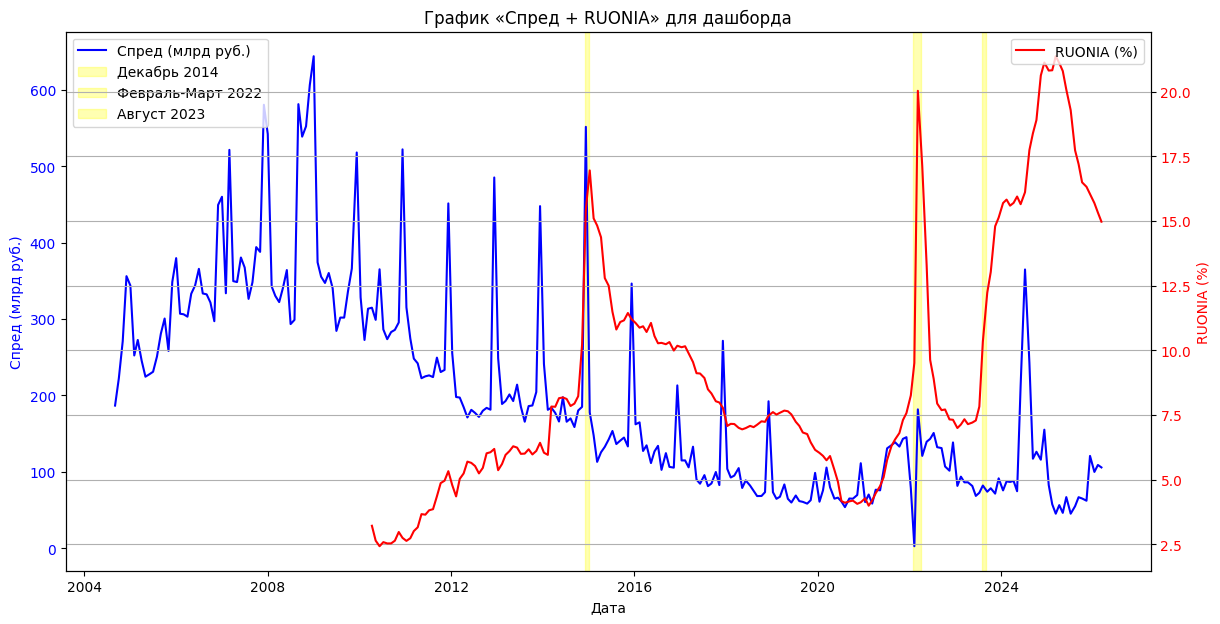

In [50]:
# График 1: Базовая логика - Спред + RUONIA с двумя осями Y
fig, ax1 = plt.subplots(figsize=(14, 7))
df.reset_index(inplace=True)
ax1.plot(df['Дата'], df['спред'], color='blue', label='Спред (млрд руб.)')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Спред (млрд руб.)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df['Дата'], df['RUONIA_avg'], color='red', label='RUONIA (%)')
ax2.set_ylabel('RUONIA (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Выделение периодов стресса
stress_periods = [
    ('2014-12-01', '2015-01-01', 'Декабрь 2014'),
    ('2022-02-01', '2022-04-01', 'Февраль-Март 2022'),
    ('2023-08-01', '2023-09-01', 'Август 2023')
]
for start, end, label in stress_periods:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='yellow', alpha=0.3, label=label)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('График «Спред + RUONIA» для дашборда')
plt.grid(True)
plt.show()

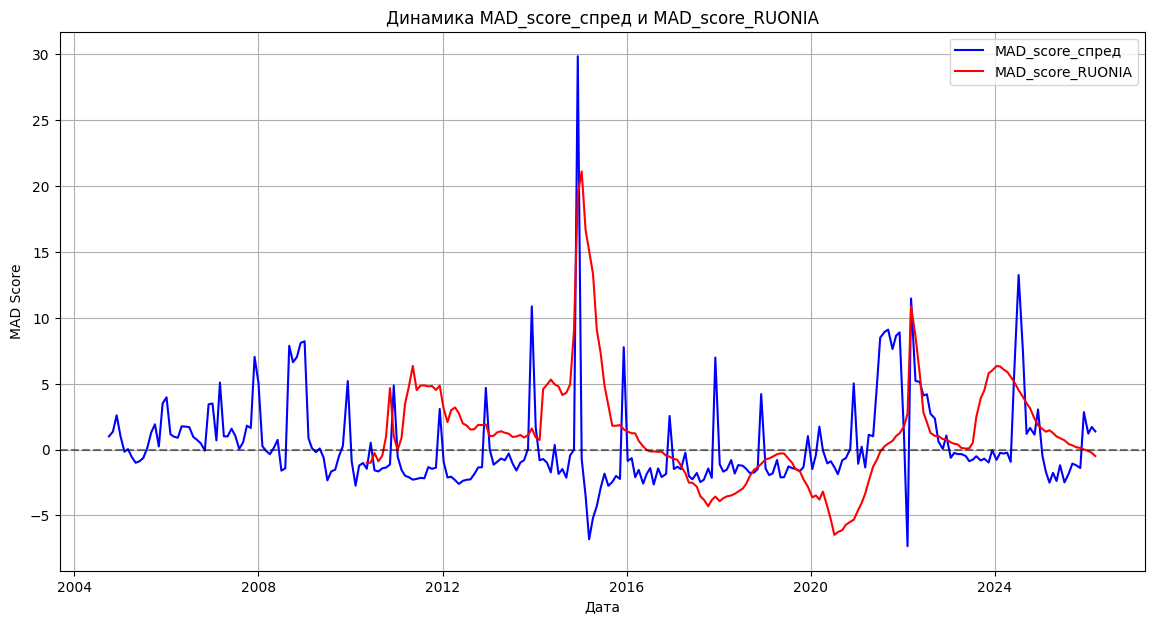

In [ ]:
# График 2: Результат нормализации - MAD_score_спред и MAD_score_RUONIA
plt.figure(figsize=(14, 7))
plt.plot(df['Дата'], df['MAD_score_спред'], label='MAD_score_спред', color='blue')
plt.plot(df['Дата'], df['MAD_score_RUONIA'], label='MAD_score_RUONIA', color='red')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Дата')
plt.ylabel('MAD Score')
plt.title('Динамика MAD_score_спред и MAD_score_RUONIA')
plt.legend()
plt.grid(True)
plt.show()

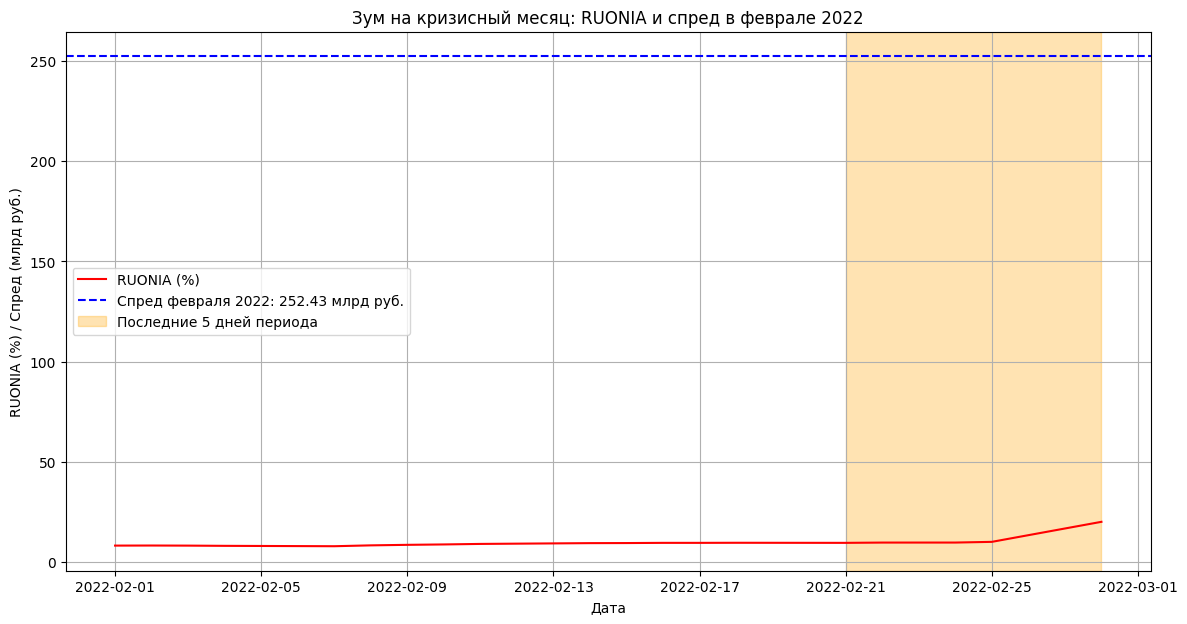

In [ ]:
# График 3: Зум на кризисный месяц - февраль 2022
# Фильтруем RUONIA за февраль 2022
feb_2022 = ruonia[(ruonia['Дата'] >= '2022-02-01') & (ruonia['Дата'] <= '2022-02-28')]

# Спред за февраль 2022 (из df, где Дата в феврале 2022)
spred_feb = df[df['Дата'].dt.month == 2]['спред'].iloc[0] if not df[df['Дата'].dt.month == 2].empty else 0

plt.figure(figsize=(14, 7))
plt.plot(feb_2022['Дата'], feb_2022['RUONIA'], color='red', label='RUONIA (%)')
plt.axhline(y=spred_feb, color='blue', linestyle='--', label=f'Спред февраля 2022: {spred_feb:.2f} млрд руб.')
plt.xlabel('Дата')
plt.ylabel('RUONIA (%) / Спред (млрд руб.)')
plt.title('Зум на кризисный месяц: RUONIA и спред в феврале 2022')

# Отмечаем конец периода усреднения (последние 5 дней февраля)
last_5_days = feb_2022['Дата'].tail(5)
plt.axvspan(last_5_days.iloc[0], last_5_days.iloc[-1], color='orange', alpha=0.3, label='Последние 5 дней периода')

plt.legend()
plt.grid(True)
plt.show()

### Возникает вопрос:

С какого года стоит обучать модель? С 2004-го, когда начинается ряд данных? Или с 2012-го, когда начинается новая эпоха с низким базовым уровнем спреда?

### Заметка: наверное стоит попробовать обучить модели на обоих периодах и сравнить результаты. Возможно, модель, обученная на данных с 2012 года, будет лучше распознавать аномалии в условиях дефицита ликвидности, тогда как модель, обученная на полном периоде, может быть более универсальной.